<header style="background-color: rgb(0, 62, 92); color: white; margin-top: 20px; padding:28px; ">
  <img src="../Images/Xlogo.png" alt="logo" width="115" style="float: left;">
  <p style=" text-align: center; font-size: 30px;">   
   <strong> APM_52448_EP - Deep Learning in Finance   </strong></p>
    <p style=" text-align: center; font-size: 30px;"> 
    <strong> Project 1 -  Deep pricing and calibration of the Heston model </strong></p>
  <p style=" text-align: left; font-size: 20px;"> Olivier Féron </p>
</header>

# 0. Setup

In [1]:
# --- Imports & global settings ---
import os, math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from scipy.stats import norm
from scipy.optimize import minimize
from time import perf_counter
import datetime
import joblib
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
# Training with early stopping on validation RMSE
os.makedirs("Data", exist_ok=True)
file_save_best_model = "Data/best_mlp.pt"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED=0
np.random.seed(SEED)
torch.manual_seed(SEED)

# 1 The Heston stochastic volatility model


The Heston Model (Heston, 1993) under the risk-neutral measure $\mathbb{Q}$:

\begin{equation}
  \begin{aligned}
    \frac{dS_t}{S_t} &= r\, dt + \sqrt{v_t}\, dW_t,\\
    dv_t &= \alpha(\beta - v_t)\, dt + \delta \sqrt{v_t}\, dB_t,\\
    d\langle W,B\rangle_t &= \rho\, dt.
  \end{aligned}
\end{equation}

We calibrate the parameter vector $\Theta=(v_0,\alpha,\beta,\delta,\rho)$.

The Heston model is well adapted to fit the volatiliy smile: Heston model's parameters can adapt lots of smile shapes.






We consider **European call options** with payoff $(S_T-K)^+$.  
In this project, calibration is performed **on call prices** (as in your Chapter 3 tutorials), not on implied volatilities.

You will use a neural network surrogate fast pricer:
$$
(\Theta, K) \mapsto C_{\text{Heston}}(K,T)
$$
for a **single maturity** $T$ (same setting as your market dataset).


# Your task

Inspired by your Chapter 3 notebooks (FastPricing_BS_Surrogate and Calibration_NN):

1) Generate simulations of the Heston model
2) Implement the Heston pricer (via Monte Carlo) to generate synthetic training data
3) Train a deep fast pricer on the synthetic data and check performance
4) Train a deep fast pricer
5) Analyze the results and find out what was wrong in the procedure

# 2 Monte Carlo simulation under the Heston model

In this project, we simulate asset price trajectories under the Heston stochastic volatility model
in order to compute option prices via Monte Carlo.


## 2.2 Time discretization

We discretize time:

$$
t_n = n \Delta t, \quad \Delta t = \frac{T}{N}.
$$

We consider correlated Brownian increments:

$$
\begin{aligned}
\Delta W_n &= \sqrt{\Delta t}\, Z_1^n, \\
\Delta B_n &= \sqrt{\Delta t}\left( \rho Z_1^n + \sqrt{1-\rho^2} Z_2^n \right).
\end{aligned}
$$

with $ Z_1^n, Z_2^n \sim \mathcal{N}(0,1) $


---

## 2.3 Variance discretization

A simple Euler scheme gives:

$$
v_{n+1} = v_n + \alpha(\beta - v_n)\Delta t
          + \delta \sqrt{v_n}\, \Delta B_n.
$$

However, this may produce negative values. A common practical fix is the **Full Truncation Euler scheme**:

$$
v_{n+1} = v_n + \alpha(\beta - v_n^+)\Delta t
          + \delta \sqrt{v_n^+}\, \Delta B_n,
$$

with $v_n^+ = \max(v_n, 0).$


---

## 2.4 Stock price discretization

Using a log-Euler scheme:

$$
S_{n+1} =
S_n \exp\left(
(r - \tfrac{1}{2} v_n^+)\Delta t
+ \sqrt{v_n^+}\, \Delta W_n
\right).
$$


<span style="color: blue;">**2.1** Implement a function that generates trajectories from the Heston model.</span>


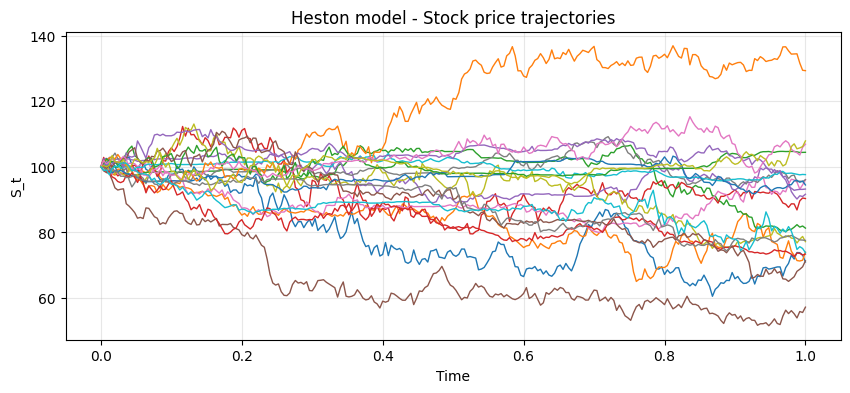

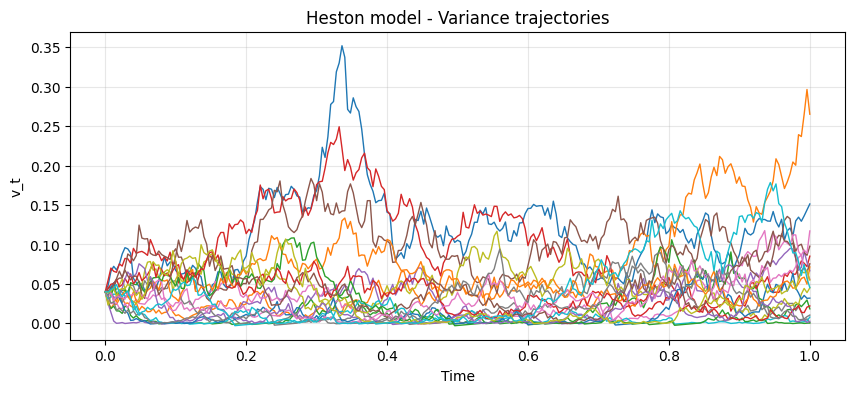

In [2]:
def simulate_heston(S0,v0,r,alpha,beta,delta,rho,T,n_steps,n_paths):
    """
    Simulate trajectories under the Heston model:
        dS_t / S_t = r dt + sqrt(v_t) dW_t
        dv_t = alpha (beta - v_t) dt + delta sqrt(v_t) dB_t
        d<W,B>_t = rho dt
    using Full Truncation Euler scheme.

    Outputs
    -------
    S : array (n_paths, n_steps+1)
    v : array (n_paths, n_steps+1)
    """

    dt = T / n_steps

    S_paths = np.zeros((n_paths, n_steps + 1))
    v_paths = np.zeros((n_paths, n_steps + 1))

    S_paths[:, 0] = S0
    v_paths[:, 0] = v0

    for t in range(n_steps):
        S_paths[:, t + 1] = S_paths[:, t] * np.exp(
            (r - 0.5 * np.maximum(v_paths[:, t], 0)) * dt + np.sqrt(np.maximum(v_paths[:, t], 0)) * np.random.normal(size=n_paths) * np.sqrt(dt))
        v_paths[:, t + 1] = v_paths[:, t] + alpha * (beta - np.maximum(v_paths[:, t], 0)) * dt + delta * np.sqrt(np.maximum(v_paths[:, t], 0)) * (rho * np.random.normal(size=n_paths) * np.sqrt(dt) + np.sqrt(1 - rho ** 2) * np.random.normal(size=n_paths) * np.sqrt(dt))

    return S_paths, v_paths



# Parameters
S0 = 100
v0 = 0.04
r = 0.02
alpha = 2.0
beta = 0.04
delta = 0.6
rho = -0.7
T = 1.0

n_steps = 250
n_paths = 20

# Simulate
S_paths, v_paths = simulate_heston(
    S0, v0, r,
    alpha, beta, delta, rho,
    T, n_steps, n_paths,
)

# Time grid
t_grid = np.linspace(0, T, n_steps + 1)

# Plot stock paths
plt.figure(figsize=(10,4))
for i in range(n_paths):
    plt.plot(t_grid, S_paths[i], lw=1)
plt.title("Heston model - Stock price trajectories")
plt.xlabel("Time")
plt.ylabel("S_t")
plt.grid(alpha=0.3)
plt.show()

# Plot variance paths
plt.figure(figsize=(10,4))
for i in range(n_paths):
    plt.plot(t_grid, v_paths[i], lw=1)
plt.title("Heston model - Variance trajectories")
plt.xlabel("Time")
plt.ylabel("v_t")
plt.grid(alpha=0.3)
plt.show()

# 3. Call option price and dataset generation

Now it is possible to approximate call option prices by Monte Carlo

<span style="color: blue;">**3.1** Implement a function that generates trajectories from the Heston model.</span>

In [3]:
def heston_call_price_mc(S0, v0, r, alpha, beta, delta, rho,T, K,n_steps,n_paths):
    return np.exp(-r * T) * np.mean(np.maximum(simulate_heston(S0, v0, r, alpha, beta, delta, rho,T, n_steps, n_paths)[0][:,-1] - K, 0))

## 3.1 Dataset generation

The objective is to randomly sample Heston parameters in the training domain 
$\mathcal{D}_{\text{domain}}$:

- $v_0 \in [0.01, 0.12]$
- $\alpha \in [0.3, 4.0]$
- $\beta \in [0.01, 0.12]$
- $\delta \in [0.1, 1.2]$
- $\rho \in [-0.95, -0.05]$
- $S_0 = 274.73$
- $K \in [60, 140]$
- $T  = 0.2$


For each $x \in \mathcal{D}_{\text{domain}}$, we then compute Monte Carlo prices $y$ 
using the Heston simulation scheme implemented previously.

The surrogate model will therefore learn the mapping:

$$
(v_0, \alpha, \beta, \delta, \rho, S_0, K, T)
\;\longmapsto\;
C_{\text{Heston}}(S_0,K,T).
$$

<span style="color: blue;"> **3.1** Implement a function `build_dataset(n_samples, n_simulations)` that builds a dataset $(x_i, y_i) \in \mathcal{D}_{\text{domain}}$, for $i = 1, \dots, n_{\text{samples}}$</span>

<span style="color: blue;">**3.2** Use this function to generate a dataset of 10,000 samples, and split the dataset into $X_{\text{train}}, y_{\text{train}}, X_{\text{val}}, y_{\text{val}}, X_{\text{test}}, y_{\text{test}}$  with a respective repartition (50%, 10%, 40%).</span>

In [4]:
# ------------------------------------------
# Dataset builder
# ------------------------------------------



def build_dataset(n_samples, n_paths, n_steps=100, verbose=True):

    def sample_domain(n_samples):
        S0 = [274.73] * n_samples
        v0 = np.random.uniform(0.01, 0.12, n_samples)
        r=np.ones(n_samples) * 0.02                     # vu que r reste fixe à 0.02
        alpha = np.random.uniform(0.3, 4.0, n_samples)
        beta = np.random.uniform(0.01, 0.12, n_samples)
        delta = np.random.uniform(0.1, 1.2, n_samples)
        rho = np.random.uniform(-0.95, -0.05, n_samples)
        T = [0.2] * n_samples
        K = np.random.uniform(60, 140, n_samples)
        X=np.stack((S0, v0, r,alpha, beta, delta, rho, T, K), axis=1)

        return X
    t0 = perf_counter()
    X = sample_domain(n_samples)
    y = np.zeros((n_samples, 1))

    for i in range(n_samples):
        y[i] = heston_call_price_mc(*X[i], n_steps=n_steps, n_paths=n_paths)
        if verbose and (i+1) % max(1, n_samples//10) == 0:
            print(f"{i+1}/{n_samples} done")
    t1 = perf_counter()
    if verbose:
        print(f"Dataset generated in {t1-t0:.2f}s (n_samples={n_samples}, n_simulations={n_paths})")
    return X, y.reshape(-1,1)

# Generate dataset
X, y = build_dataset(n_samples=10000,n_paths=5000,n_steps=50)

# ------------------------------------------
# Train / Val / Test split
# ------------------------------------------

def random_split(X, y, train_ratio=0.5, val_ratio=0.1):

    # Lengths    
    n = X.shape[0]   
    ny = y.shape[0]
    # Check of equal number of samples
    if n != ny:
        raise ValueError(f"X and y must have the same number of samples (X:{n}, y:{ny})")

    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)
    
    # Random permutation of the samples
    idx = np.random.permutation(n)
    
    # Split indices
    idx_train = idx[:n_train]
    idx_val   = idx[n_train:n_train + n_val]
    idx_test  = idx[n_train + n_val:]


    # Split Data
    X_train, y_train = X[idx_train], y[idx_train]
    X_val,   y_val   = X[idx_val],   y[idx_val]
    X_test,  y_test  = X[idx_test],  y[idx_test]
        
    return (X_train, y_train), (X_val, y_val), (X_test, y_test)

    

(X_train, y_train), (X_val, y_val), (X_test, y_test) = random_split(X, y)

print("Train:", X_train.shape)
print("Val  :", X_val.shape)
print("Test :", X_test.shape)

1000/10000 done
2000/10000 done
3000/10000 done
4000/10000 done
5000/10000 done
6000/10000 done
7000/10000 done
8000/10000 done
9000/10000 done
10000/10000 done
Dataset generated in 207.55s (n_samples=10000, n_simulations=5000)
Train: (5000, 9)
Val  : (1000, 9)
Test : (4000, 9)


## 3.2 Data normalization

<span style="color: blue;"> **3.3** Standardize all the data in an appropriate way</span>


In [5]:
# YOUR CODE HERE

from sklearn.preprocessing import StandardScaler
scaler_X = StandardScaler().fit(X_train)
X_train_s = scaler_X.transform(X_train)
X_val_s   = scaler_X.transform(X_val)
X_test_s  = scaler_X.transform(X_test)

scaler_y = StandardScaler().fit(y_train) 
y_train_s = scaler_y.transform(y_train)
y_val_s   = scaler_y.transform(y_val)
y_test_s  = scaler_y.transform(y_test)

In [6]:
# Transform Dataset in Torch objects
train_ds = TensorDataset(torch.tensor(X_train_s, dtype=torch.float32),
                         torch.tensor(y_train_s,   dtype=torch.float32))
val_ds   = TensorDataset(torch.tensor(X_val_s,   dtype=torch.float32),
                         torch.tensor(y_val_s,     dtype=torch.float32))
test_ds  = TensorDataset(torch.tensor(X_test_s,  dtype=torch.float32),
                         torch.tensor(y_test_s,    dtype=torch.float32))

train_loader = DataLoader(train_ds, batch_size=64, shuffle=False)  # Shuffle => mix or not the data. False => keep time order of the data
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False)

# Sanity check
print("X_train mean (approx):", X_train_s.mean(axis=0))
print("X_train std  (approx):", X_train_s.std(axis=0))

# Saving scaling parameters
joblib.dump(scaler_X, "scaler_X.joblib")
joblib.dump(scaler_y, "scaler_y.joblib")

X_train mean (approx): [ 1.42108547e-11  3.20876659e-16  5.51642065e-16 -5.12119236e-15
 -4.61642391e-15  9.14690546e-16  8.58784155e-15 -1.80688797e-14
 -5.01709785e-16]
X_train std  (approx): [0. 1. 0. 1. 1. 1. 1. 0. 1.]


['scaler_y.joblib']

## 4. Surrogate model: a simple MLP

Now that all is ready to train a Neural Network, we consider a simple MLP surrogate model.

We propose a fully-connected network:
- **input dim:** 5 (features $(v_0, \alpha, \beta, \delta, \rho, S_0, K, T)$ standardized)
- **Hidden layers:** 3 layers with sizes 128 --> 128 --> 64, all with ReLU
- **Output dim:** 1 (scaled (standardized) price)
- **Loss function:** MSE (nn.MSELoss)
- **Optimizer:** Adam (Learning rate 1e$^{-3}$

<span style="color: blue;">**4.1** Build the class MLP with the above characteristics  </span>

<span style="color: blue;">**4.2** Implement the function `run_epoch(loader, train)` that runs one epoch</span>
- <span style="color: blue;">sets model.train() if train=True otherwise model.eval()</span>
- <span style="color: blue;">iterates over the loader, sends</span>
- <span style="color: blue;">returns the losses </span>

<span style="color: blue;">**4.3** Implement the training procedure on 250 Epochs, with an overfitting control  </span>
- <span style="color: blue;">with a patience counter of 20 (if no loss decrease during 20 Epochs, then stop</span>
- <span style="color: blue;">save the best model in `Data/best_mlp.pt`</span>

<span style="color: blue;">**4.4** Plot the MSE losses (Learning Curves) for the train and val sets  </span>

Epoch 020 | Train MSE=0.000658 | Val MSE=0.000925
Epoch 040 | Train MSE=0.000492 | Val MSE=0.000612
Epoch 060 | Train MSE=0.000444 | Val MSE=0.000654
Early stopping.


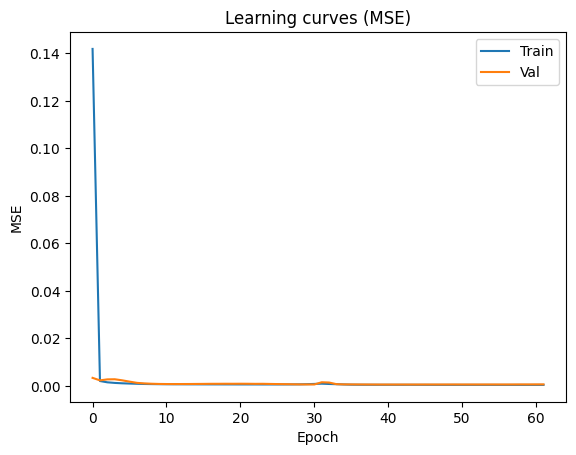

In [7]:
# YOUR CODE HERE

# Training with early stopping on validation RMSE
import math
best_val = math.inf
patience= 20
EPOCHS = 250
file_save_best_model = "fast_pricing_mlp.pt"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Model
class MLP(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64,1)
        )
    def forward(self, x):
        return self.net(x)


model = MLP(in_dim=X_train_s.shape[1]).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


def run_epoch(loader, train=False):
    if train: model.train()
    else: model.eval()
    losses = []
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        pred = model(xb)
        loss = criterion(pred, yb)
        if train:
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()
        losses.append(loss.item())
    return np.mean(losses)


patience_cnt = 0
train_data, val_data = [], []
for epoch in range(1, EPOCHS+1):
    tr = run_epoch(train_loader, train=True) # Can mix the order since we are not working with time series
    va = run_epoch(val_loader,   train=False) # Must keep the order to match with predicted value
    train_data.append(tr); val_data.append(va)
    val_mse = va
    if val_mse < best_val - 1e-6:
        best_val = val_mse
        patience_cnt = 0
        torch.save(model.state_dict(), file_save_best_model)
    else:
        patience_cnt += 1
    if epoch % 20 == 0:
        print(f"Epoch {epoch:03d} | Train MSE={tr:.6f} | Val MSE={val_mse:.6f}")
    if patience_cnt >= patience:
        print("Early stopping.")
        break

plt.figure()
plt.plot(train_data)
plt.plot(val_data)
plt.title("Learning curves (MSE)")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend(["Train","Val"])
plt.show()

## 5. Evaluation (accuracy)

Now the surrogate model is trained, let's evaluate its performance on the test set

<span style="color: blue;">**5.1** Load the best model saved in `file_save_best_model` and the scaling parameters with command `joblib.load` and evaluate with `model.eval()`</span>

<span style="color: blue;">**5.2** Compute the predicted `y_test_pred` from X_test (test_loader tensor) and unscale to get `y_test_hat`</span>

<span style="color: blue;">**5.3** Compute the MAE and RMSE, and give the scatter plot MC price vs. NN price </span>

<span style="color: blue;">**5.4** Give the scatter plot BS price vs. NN price </span>

In [8]:
def Black_Scholes_Formula(vol, risk_free_rate, current_price, strike, maturity):
    r"""
    Black_Scholes_Formula(vol, risk_free_rate, current_price, strike, maturity)
    Function computing the Black-Scholes formula to obtain the price of a Call option
    
    Inputs
    ----------
    vol            : volatility of the underlying
    risk_free_rate : value of the risk free rate
    current_price  : current value of the underlying price (X_t)
    strike         : value of the strike (K)
    maturity       : Maturity of the option (T-t)

    Output
    -------
    Value          : Call option price from BS formula : X0 \Phi(d_1) - K e^{-r(T_t)} \Phi(d_2)
    """
    # Computation of d_1 and d_2 of the Black-Scholes Formula
    d_1 = (np.log(current_price/strike) + (risk_free_rate + 0.5 * vol**2)*maturity)/(vol * np.sqrt(maturity))
    d_2 = d_1 - vol * np.sqrt(maturity)
    # Black-Scholes formula
    Value = current_price * norm.cdf(d_1) - strike * np.exp(- risk_free_rate * maturity) * norm.cdf(d_2)
    return Value



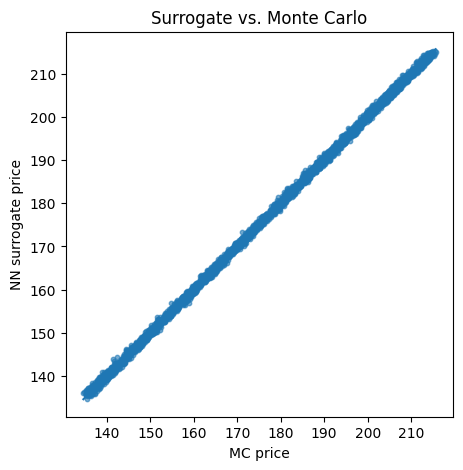

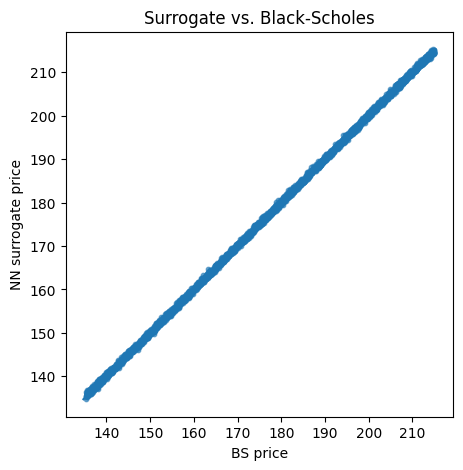

In [9]:
# YOUR CODE HERE
# Load the best model (saved during learning)
model.load_state_dict(torch.load(file_save_best_model, map_location=device))
model.eval()

# Also import the scaling parameters
scaler_X = joblib.load("scaler_X.joblib")
scaler_y = joblib.load("scaler_y.joblib")
                       
# Prediction on the test set
with torch.no_grad():
    y_test_pred = []
    for xb, _ in test_loader:
        xb = xb.to(device)
        y_test_pred.append(model(xb).cpu().numpy())
    y_test_pred = np.concatenate(y_test_pred, axis=0)

# Unscale
y_test_hat = scaler_y.inverse_transform(y_test_pred)
# MAE and RMSE

# Scatterplot MC vs. NN
plt.figure(figsize=(5,5))
plt.scatter(y_test, y_test_hat, s=10, alpha=0.6)
m = float(min(y_test.min(), y_test_hat.min()))
M = float(max(y_test.max(), y_test_hat.max()))
plt.plot([m, M], [m, M])
plt.xlabel("MC price")
plt.ylabel("NN surrogate price")
plt.title("Surrogate vs. Monte Carlo")
plt.show()


##########################################
# BS vs. NN
# Compute Black-Scoles prices
sigma = X_test[:,1]**0.5
r = X_test[:,2]
S0 = X_test[:,0]
K = X_test[:,8]
Tmt = X_test[:,7]

y_bs = Black_Scholes_Formula(sigma, r, S0, K, Tmt)
# Scatterplot MC vs. NN
plt.figure(figsize=(5,5))
plt.scatter(y_bs, y_test_hat, s=10, alpha=0.6)
m = float(min(y_bs.min(), y_test_hat.min()))
M = float(max(y_bs.max(), y_test_hat.max()))
plt.plot([m, M], [m, M])
plt.xlabel("BS price")
plt.ylabel("NN surrogate price")
plt.title("Surrogate vs. Black-Scholes")
plt.show()


On voit que les prix données par le modèle surrogate basés sur le modèle de Heston sont très similaires à ceux qu'on obtiendrait en faisant un monte carlo. Ce qui justifie que cela constinue une benchmark assez rapide dans la pratique. 

De plus, ces prix sont assez similaires à ceux obtenus par le modèle de Black scholes, ce qui confirme que le modèle de black scholes eest une excellente approximation

# 6 Calibration on real data

The objective is to calibrate the Black-Scholes model, i.e. to estimated the implied volatility $\sigma_\text{imp}$.

We propose to estimate $\theta = (v_0, \alpha, \beta, \delta, \rho)$ by minimizing the quadrati error:
\begin{equation}
\sigma_\text{imp} = \arg\min_{\theta} J^{method}(\theta) 
\end{equation}
with 
\begin{equation}
J^{method}(\theta)  = \frac{1}{I}\sum_{i=1}^I \| C^{mkt}_i - C^{NN}_i(\theta) \|^2
\end{equation}
where $C^{NN}_i(\sigma)$ is the price obtained from the NN Surrogate fast pricer. 





### 6.1 First step  : download and prepare the data

In [10]:
# Load AAPL calls (semicolon-separated)
df = pd.read_csv("AAPL_Call.csv", sep=";", thousands=",")

df.head(), df.columns, df.shape

S0 = 274.73
r = 0.01
# Price = mid (bid/ask) 
C_mkt_series = (df["Bid"] + df["Ask"]) / 2.0
#else:
#C_mkt_series = df["Last Price"]

K_vec     = df["Strike"].to_numpy(dtype=float)
C_mkt_vec = C_mkt_series.to_numpy(dtype=float)


d = datetime.date(2025, 12, 26)
D = datetime.date(2026, 12, 18)
Tmt = (D - d).days / 365.0  # T in year
T_vec = np.full_like(K_vec, Tmt, dtype=float)

print(K_vec, T_vec)

[  5.  10.  15.  20.  25.  30.  35.  40.  45.  50.  60.  70.  80.  85.
  90.  95. 100. 105. 110. 115. 120. 125. 130. 135. 140. 145. 150. 155.
 160. 165. 170. 175. 180. 185. 190. 195. 200. 205. 210. 215. 220. 225.
 230. 235. 240. 245. 250. 255. 260. 265. 270. 275. 280. 285. 290. 295.
 300. 305. 310. 315. 320. 325. 330. 335. 340. 345. 350. 360. 370. 380.
 390. 400. 410. 420. 430. 440. 450. 460. 470. 480. 490. 500. 510. 520.
 530.] [0.97808219 0.97808219 0.97808219 0.97808219 0.97808219 0.97808219
 0.97808219 0.97808219 0.97808219 0.97808219 0.97808219 0.97808219
 0.97808219 0.97808219 0.97808219 0.97808219 0.97808219 0.97808219
 0.97808219 0.97808219 0.97808219 0.97808219 0.97808219 0.97808219
 0.97808219 0.97808219 0.97808219 0.97808219 0.97808219 0.97808219
 0.97808219 0.97808219 0.97808219 0.97808219 0.97808219 0.97808219
 0.97808219 0.97808219 0.97808219 0.97808219 0.97808219 0.97808219
 0.97808219 0.97808219 0.97808219 0.97808219 0.97808219 0.97808219
 0.97808219 0.97808219 0.978082

In [19]:
df

,Contract Name,Strike,Last Price,Bid,Ask,Change,Volume,Open Interest
0,AAPL261218C00005000,5,264.64,267.50,271.30,0.0,1.0,2.0
1,AAPL261218C00010000,10,245.23,251.00,254.85,0.0,10.0,15.0
2,AAPL261218C00015000,15,186.06,238.95,242.35,0.0,4.0,5.0
3,AAPL261218C00020000,20,240.80,255.65,259.55,0.0,1.0,5.0
4,AAPL261218C00025000,25,184.65,229.35,232.75,0.0,1.0,2.0
...,...,...,...,...,...,...,...,...
80,AAPL261218C00490000,490,0.51,0.43,0.47,0.0,1.0,42.0
81,AAPL261218C00500000,500,0.40,0.36,0.40,0.0,6.0,223.0
82,AAPL261218C00510000,510,0.40,0.31,0.35,0.0,5.0,26.0
83,AAPL261218C00520000,520,0.30,0.27,0.31,0.0,100.0,305.0


In [ ]:
#definir X_mkt
X_mkt = np.stack((np.full_like(K_vec, S0),  # S0
                 np.full_like(K_vec, 0.01), # v0
                 np.full_like(K_vec, r),    # r
                 np.full_like(K_vec, 2.0),  # alpha
                 np.full_like(K_vec, 0.04), # beta
                 np.full_like(K_vec, 0.6),  # delta
                 np.full_like(K_vec, -0.7), # rho
                 T_vec,                     # T
                 K_vec                      # K
                 ), axis=1)

### 6.2 Cost function

<span style="color: blue;">**6.1** Build in the code below the function `nn_price_call_heston` that computes the price from the NN Surrogate Fast pricer.</span>

In [14]:
# Global variables expected by loss_nn_heston
K_mkt = K_vec.copy()
T_mkt = T_vec.copy()
C_mkt = C_mkt_vec.copy()

In [25]:
def build_features_heston(v0, alpha, beta, delta, rho, S0, K, T):
    '''
    Creates the NN input features for the Heston surrogate model.

    All inputs must be broadcastable arrays of same length.
    '''
    v0    = np.asarray(v0, dtype=float)
    alpha = np.asarray(alpha, dtype=float)
    beta  = np.asarray(beta, dtype=float)
    delta = np.asarray(delta, dtype=float)
    rho   = np.asarray(rho, dtype=float)
    S0    = np.asarray(S0, dtype=float)
    K     = np.asarray(K, dtype=float)
    T     = np.asarray(T, dtype=float)

    # Broadcast all arrays to the same shape
    v0, alpha, beta, delta, rho, S0, K, T = np.broadcast_arrays(
        v0, alpha, beta, delta, rho, S0, K, T
    )

    # Constant rate with same shape
    r = np.full_like(v0, 0.01, dtype=float)

    # Ensure all arrays have the same shape
    assert v0.shape == alpha.shape == beta.shape == delta.shape == rho.shape == S0.shape == K.shape == T.shape, \
        f"Shape mismatch: v0={v0.shape}, alpha={alpha.shape}, beta={beta.shape}, delta={delta.shape}, rho={rho.shape}, S0={S0.shape}, K={K.shape}, T={T.shape}"

    return np.stack([S0, v0, r, alpha, beta, delta, rho, T, K], axis=1)

In [28]:
def build_features_heston(v0, alpha, beta, delta, rho, S0, K, T):
    '''
    Creates the NN input features for the Heston surrogate model.

    All inputs must be broadcastable arrays of same length.
    '''
    v0    = np.asarray(v0, dtype=float)
    alpha = np.asarray(alpha, dtype=float)
    beta  = np.asarray(beta, dtype=float)
    delta = np.asarray(delta, dtype=float)
    rho   = np.asarray(rho, dtype=float)
    S0    = np.asarray(S0, dtype=float)
    K     = np.asarray(K, dtype=float)
    T     = np.asarray(T, dtype=float)

    # Broadcast all arrays to the same shape
    v0, alpha, beta, delta, rho, S0, K, T = np.broadcast_arrays(
        v0, alpha, beta, delta, rho, S0, K, T
    )

    # Constant rate with same shape
    r = np.full_like(v0, 0.01, dtype=float)

    # Ensure all arrays have the same shape
    assert v0.shape == alpha.shape == beta.shape == delta.shape == rho.shape == S0.shape == K.shape == T.shape, \
        f"Shape mismatch: v0={v0.shape}, alpha={alpha.shape}, beta={beta.shape}, delta={delta.shape}, rho={rho.shape}, S0={S0.shape}, K={K.shape}, T={T.shape}"

    return np.column_stack([S0, v0, r, alpha, beta, delta, rho, T, K])

In [29]:


def nn_price_call_heston(model, scaler_X, scaler_y, X):
    '''
    Uses the trained surrogate model to predict call prices for given Heston parameters and option specs.

    Inputs
    ------
    model : trained surrogate model (PyTorch)
    scaler_X : scaler used to scale the input features during training (sklearn StandardScaler)
    scaler_y : scaler used to scale the target during training (sklearn StandardScaler)
    X : array of shape (n_samples, 8) containing the input features [v0, alpha, beta, delta, rho, S0, K, T]

    Output
    ------
    C : array of shape (n_samples,) containing the predicted call prices
    '''
    # Scale input features
    X_s = scaler_X.transform(X)
    
    # Predict scaled price with the surrogate model
    with torch.no_grad():
        X_tensor = torch.tensor(X_s, dtype=torch.float32).to(next(model.parameters()).device)
        y_pred_s = model(X_tensor).cpu().numpy()
    
    # Unscale predicted price
    C = scaler_y.inverse_transform(y_pred_s)
    
    return C.reshape(-1)

Calibrated parameters:
v0    = 0.03999993532534178
alpha = 1.0
beta  = 0.039999731615333774
delta = 0.5000023720705723
rho   = -0.49999791803852794
Final loss = 3234.187864383064


/tmp/ipykernel_2011618/775388878.py:67: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  C_nn[i] = nn_price_call_heston(model, scaler_X, scaler_y, X_i)
/tmp/ipykernel_2011618/775388878.py:67: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  C_nn[i] = nn_price_call_heston(model, scaler_X, scaler_y, X_i)
/tmp/ipykernel_2011618/775388878.py:67: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  C_nn[i] = nn_price_call_heston(model, scaler_X, scaler_y, X_i)
/tmp/ipykernel_2011618

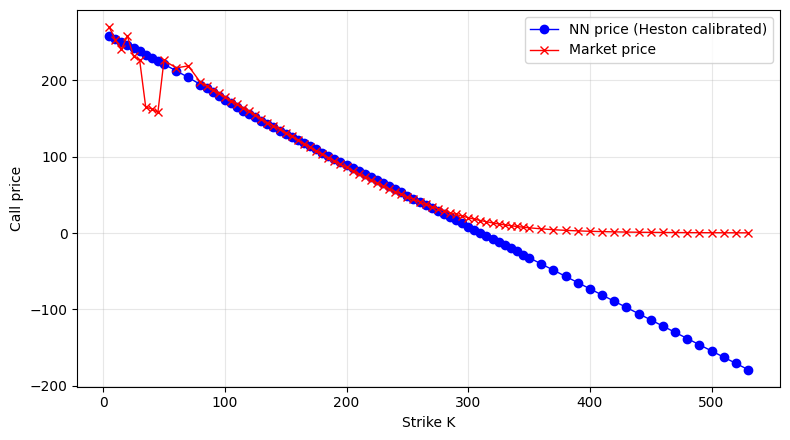

In [30]:

    

def loss_nn_heston(theta):
    '''
    theta = [v0, alpha, beta, delta, rho]
    '''
    v0, alpha, beta, delta, rho = theta

    # Génération des caractéristiques
    X = build_features_heston(
        v0 * np.ones_like(K_mkt),
        alpha * np.ones_like(K_mkt),
        beta * np.ones_like(K_mkt),
        delta * np.ones_like(K_mkt),
        rho * np.ones_like(K_mkt),
        S0 * np.ones_like(K_mkt),
        K_mkt,
        T_mkt
    )


    # Calcul des prix avec le modèle
    C = nn_price_call_heston(model, scaler_X, scaler_y, X).reshape(-1)

    # Vérification des dimensions
    assert C.shape == C_mkt.shape, f"Dimensions incompatibles : C={C.shape}, C_mkt={C_mkt.shape}"

    # Calcul de la perte
    return float(np.mean((C - C_mkt) ** 2))

# Initial guess
theta_0 = np.array([0.04, 1.0, 0.04, 0.5, -0.5])

# Bounds
HES_BOUNDS = [
    (0.001, 0.2),     # v0
    (0.1, 5.0),       # alpha
    (0.001, 0.2),     # beta
    (0.05, 2.0),      # delta
    (-0.999, 0.999)   # rho
]

# Vérification des dimensions des données
assert K_mkt.shape == T_mkt.shape == C_mkt.shape, "Les dimensions de K_mkt, T_mkt et C_mkt doivent correspondre."



# Minimisation
res = minimize(loss_nn_heston, theta_0, bounds=HES_BOUNDS, method="L-BFGS-B")

theta_star = res.x
print("Calibrated parameters:")
print("v0    =", theta_star[0])
print("alpha =", theta_star[1])
print("beta  =", theta_star[2])
print("delta =", theta_star[3])
print("rho   =", theta_star[4])
print("Final loss =", res.fun)

C_nn = np.zeros_like(K_vec, dtype=float)

for i, (Ki, Ti) in enumerate(zip(K_vec, T_vec)):

    X_i = build_features_heston(
    theta_star[0], theta_star[1], theta_star[2], theta_star[3], theta_star[4],
    S0, Ki, Ti
)

    C_nn[i] = nn_price_call_heston(model, scaler_X, scaler_y, X_i)


    

plt.figure(figsize=(8, 4.5))

plt.plot(K_vec, C_nn, 'o-', color='b', lw=1,
         label='NN price (Heston calibrated)')
plt.plot(K_vec, C_mkt_vec, 'x-', color='r', lw=1,
         label='Market price')

plt.xlabel('Strike K')
plt.ylabel('Call price')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

On observe qye pour des valeurs du strike inférieure à 275, le modèle de Heston calibré (dont les prix sont tirés du modèle surrogate) donne des prix assez fidèles à ceux du marché, mais au delà, on s'écarte fortement du prix du marché. 

Ceci peut s'expliquer par le fait que hors du domaine dans lequel il a été entraîné, le modèle surrogate n'est plus valablet et ces prédictions ne peuvent plus constituer une valeur de marché. 

<span style="color: blue;">**6.4** Analyze the results. What do yu think the best way to impoved in the code above (numer of simulations, $\mathcal{D}_\text{domain}$; layers in deep NN...) ? </span> You can write your answer in the next markdown box or change the code above to improve the results (or both !)

# References


1) Steven Heston. A Closed-Form Solution for Options with Stochastic Volatility with Applications to Bond and Currency Options. RFS, 1993

2) Course notebooks: FastPricing_BS_Surrogate, Calibration_NN
